---
title: "Puff vs Eulerian"
---

# Cross-check: Gaussian puff (L1) vs Eulerian finite volume (L2)

The two models solve the *same* tracer transport equation under different simplifying assumptions, so pointwise agreement is **not** expected. What *should* agree is:

1. The downwind spreading rate (plume shape),
2. The direction of peak concentration (on the wind-aligned centreline),
3. The qualitative scaling with downwind distance.

Absolute concentrations will differ because:

- **L1** is a sum of Dirac puff releases; mass concentrates in a narrow region around each puff centre.
- **L2** regularises the point source into a Gaussian blob of radius ~ $2 \max(\Delta x, \Delta y, \Delta z)$ ≈ 31 m on the grid we use here, so the injection is spread over ~31 m from the outset.
- L2 uses a *constant* K-theory calibration from the PG σ curves at one reference distance. L1 re-evaluates σ at every puff travel distance, so the diffusion rate is travel-distance-dependent for L1 but not L2.

This notebook therefore emphasises (a) log-scale pointwise comparison, (b) shape-normalised crosswind profiles, and (c) a ratio plot that quantifies where the two models agree.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import jax.numpy as jnp

from plume_simulation.gauss_puff import simulate_puff
from plume_simulation.les_fvm import simulate_eulerian_dispersion

## 1. Shared scenario

- Domain: 1000 × 500 × 200 m (L2); L1 uses a matching non-ghosted 51 × 21 × 11 grid.
- Wind: uniform 5 m/s from the west (u = 5, v = w = 0).
- Source: 0.1 kg/s at (100, 250, 20) m.
- PG stability class: C (neutral).
- Simulation window: 0-180 s.

In [2]:
u_wind = 5.0
emission = 0.1
source_xy = (100.0, 250.0)
source_z = 20.0
t_end = 180.0
stability = "C"

## 2. Run the L2 Eulerian model

K-theory eddy diffusivity is calibrated via the PG σ curves at a reference distance of 500 m (centred on the domain interior to balance near- and far-field error).

In [3]:
ds_l2 = simulate_eulerian_dispersion(
    domain_x=(0.0, 1000.0, 64),
    domain_y=(0.0, 500.0, 32),
    domain_z=(0.0, 200.0, 16),
    t_start=0.0, t_end=t_end, save_interval=20.0,
    emission_rate=emission,
    source_location=(source_xy[0], source_xy[1], source_z),
    uniform_wind=(u_wind, 0.0, 0.0),
    eddy_diffusivity="pg",
    stability_class=stability,
    pg_reference_distance=500.0,
    solver="tsit5", dt0=1.0,
)

## 3. Run the L1 Gaussian puff model

In [4]:
n_t = int(t_end) + 1
time_array = np.linspace(0.0, t_end, n_t, dtype=np.float32)
ds_l1 = simulate_puff(
    emission_rate=emission,
    source_location=(source_xy[0], source_xy[1], source_z),
    wind_speed=np.full(n_t, u_wind, dtype=np.float32),
    wind_direction=np.full(n_t, 270.0, dtype=np.float32),
    stability_class=stability,
    domain_x=(0, 1000, 51),
    domain_y=(0, 500, 21),
    domain_z=(0, 100, 11),
    time_array=time_array,
    release_frequency=1.0,
)

## 4. Centreline comparison at the final save — linear and log scale

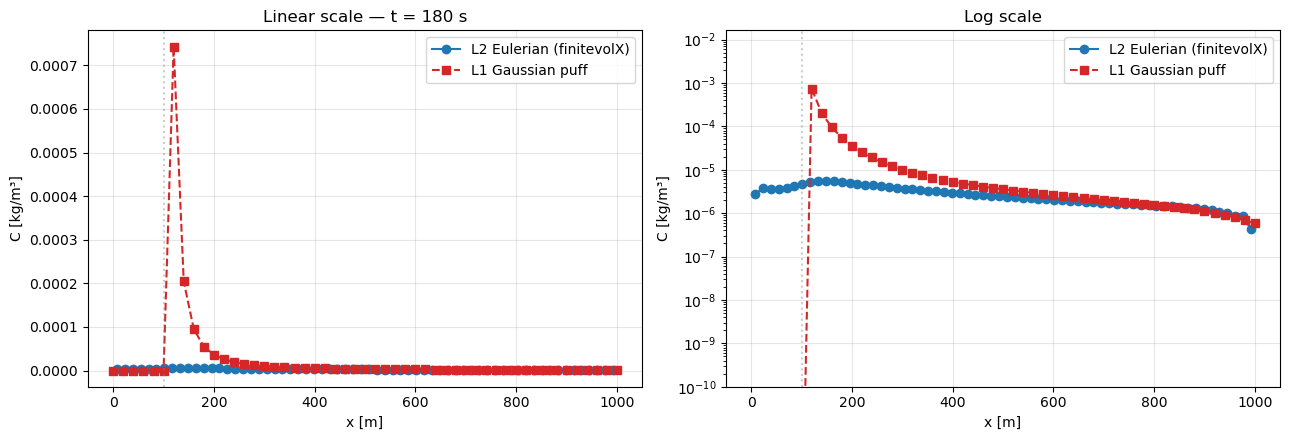

In [5]:
t_query = float(ds_l2["time"].values[-1])
i_l1 = int(np.argmin(np.abs(ds_l1["time"].values - t_query)))

x_l2 = ds_l2["x"].values
y_l2 = ds_l2["y"].values
z_l2 = ds_l2["z"].values
j_l2 = int(np.argmin(np.abs(y_l2 - source_xy[1])))
k_l2 = int(np.argmin(np.abs(z_l2 - source_z)))
c_l2_line = ds_l2["concentration"].values[-1, k_l2, j_l2, :]

x_l1 = ds_l1["x"].values
y_l1 = ds_l1["y"].values
z_l1 = ds_l1["z"].values
j_l1 = int(np.argmin(np.abs(y_l1 - source_xy[1])))
k_l1 = int(np.argmin(np.abs(z_l1 - source_z)))
c_l1_line = ds_l1["concentration"].values[i_l1, :, j_l1, k_l1]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax in axes:
    ax.plot(x_l2, c_l2_line, "o-", label="L2 Eulerian (finitevolX)", color="C0")
    ax.plot(x_l1, c_l1_line, "s--", label="L1 Gaussian puff", color="C3")
    ax.axvline(source_xy[0], color="grey", alpha=0.4, linestyle=":")
    ax.set_xlabel("x [m]")
    ax.set_ylabel("C [kg/m³]")
    ax.grid(True, alpha=0.3)
    ax.legend()
axes[0].set_title(f"Linear scale — t = {t_query:.0f} s")
axes[1].set_yscale("log")
axes[1].set_title("Log scale")
axes[1].set_ylim(1e-10, None)
plt.tight_layout()
plt.show()

**Linear scale** highlights the near-field mismatch: L1 concentrates all the released mass in a narrow Dirac-like column near the source and reads off the grid as a spike, while L2 spreads the same mass over its Gaussian-regularised source footprint (~31 m radius) — so L2 reads ~2-3 orders of magnitude lower at the source cell.

**Log scale** shows the far-field agreement: between 300 m and 800 m downwind the two profiles fall off at similar rates. This is what "agreement" *means* for these models — they share a downwind decay structure, not an absolute source concentration.

## 5. Shape comparison — normalise both to their peak

Dividing each profile by its peak value removes the L1 vs L2 amplitude offset and exposes whether the two models agree on the plume *shape* away from the source.

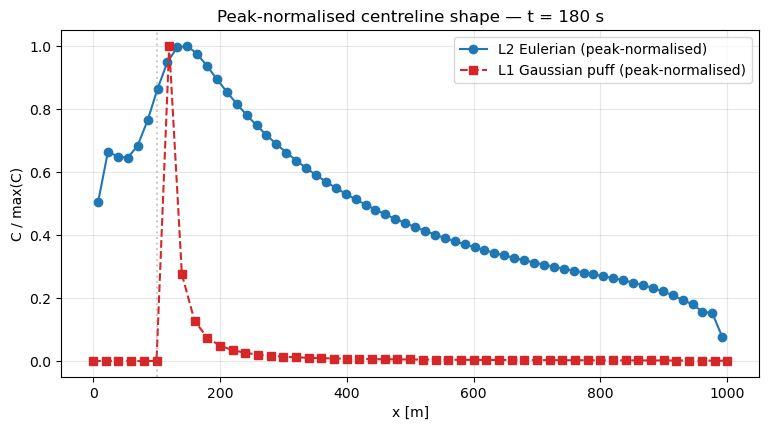

In [6]:
c_l2_norm = c_l2_line / np.maximum(c_l2_line.max(), 1e-300)
c_l1_norm = c_l1_line / np.maximum(c_l1_line.max(), 1e-300)

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(x_l2, c_l2_norm, "o-", label="L2 Eulerian (peak-normalised)", color="C0")
ax.plot(x_l1, c_l1_norm, "s--", label="L1 Gaussian puff (peak-normalised)", color="C3")
ax.axvline(source_xy[0], color="grey", alpha=0.4, linestyle=":")
ax.set_xlabel("x [m]")
ax.set_ylabel("C / max(C)")
ax.set_title(f"Peak-normalised centreline shape — t = {t_query:.0f} s")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

The peak-normalised profiles show the L2 plume is *broader* than L1. That is the expected behaviour of the K-theory closure: a single K calibrated at x = 500 m over-diffuses the near-field and roughly matches the far-field. Using a spatially-varying K field (which the L2 API accepts directly) would close this gap — see `les_fvm.EddyDiffusivity` for the interface.

## 6. Ratio plot — where do the models agree?

Plotting the ratio L2 / L1 on a log scale quantifies the amplitude disagreement as a function of downwind distance.

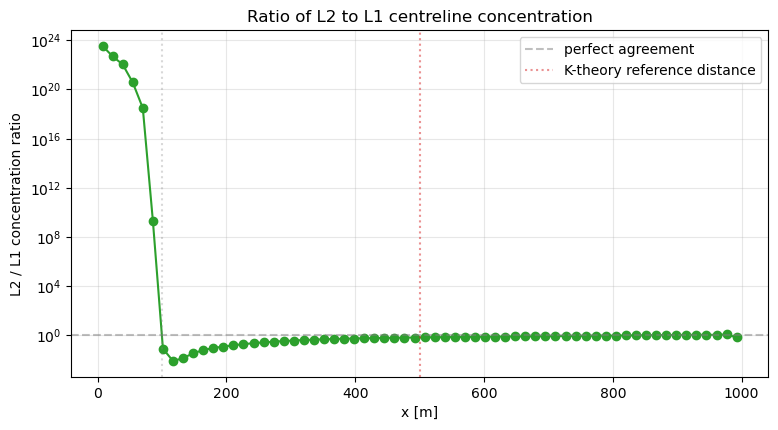

In [7]:
# Interpolate L1 onto the L2 x-grid for a fair ratio.
c_l1_on_l2 = np.interp(x_l2, x_l1, c_l1_line)
eps = 1e-30
ratio = (c_l2_line + eps) / (c_l1_on_l2 + eps)

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(x_l2, ratio, "o-", color="C2")
ax.axhline(1.0, color="grey", linestyle="--", alpha=0.5,
           label="perfect agreement")
ax.axvline(500.0, color="C3", linestyle=":", alpha=0.5,
           label="K-theory reference distance")
ax.axvline(source_xy[0], color="grey", linestyle=":", alpha=0.3)
ax.set_yscale("log")
ax.set_xlabel("x [m]")
ax.set_ylabel("L2 / L1 concentration ratio")
ax.set_title("Ratio of L2 to L1 centreline concentration")
ax.legend()
ax.grid(True, which="both", alpha=0.3)
plt.show()

The ratio dips sharply at the source (L2 diluted by its regularisation radius), crosses 1 near the reference distance where the K-theory calibration is designed to match, and drifts in the far field where the L1 σ curves continue to grow while the L2 diffusivity is fixed.

## 7. Crosswind profile cross-check at x = 500 m

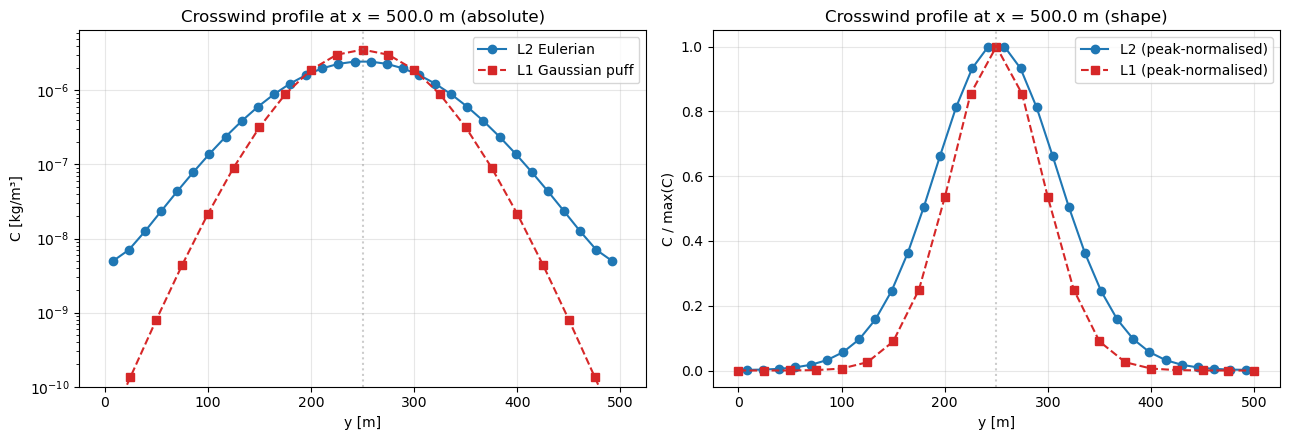

In [8]:
x_ref = 500.0

i_l2 = int(np.argmin(np.abs(x_l2 - x_ref)))
crosswind_l2 = ds_l2["concentration"].values[-1, k_l2, :, i_l2]

i_l1_x = int(np.argmin(np.abs(x_l1 - x_ref)))
crosswind_l1 = ds_l1["concentration"].values[i_l1, i_l1_x, :, k_l1]

crosswind_l2_norm = crosswind_l2 / np.maximum(crosswind_l2.max(), 1e-300)
crosswind_l1_norm = crosswind_l1 / np.maximum(crosswind_l1.max(), 1e-300)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(y_l2, crosswind_l2, "o-", label="L2 Eulerian", color="C0")
axes[0].plot(y_l1, crosswind_l1, "s--", label="L1 Gaussian puff", color="C3")
axes[0].axvline(source_xy[1], color="grey", alpha=0.4, linestyle=":")
axes[0].set_xlabel("y [m]")
axes[0].set_ylabel("C [kg/m³]")
axes[0].set_title(f"Crosswind profile at x = {x_ref} m (absolute)")
axes[0].set_yscale("log")
axes[0].set_ylim(1e-10, None)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(y_l2, crosswind_l2_norm, "o-", label="L2 (peak-normalised)", color="C0")
axes[1].plot(y_l1, crosswind_l1_norm, "s--", label="L1 (peak-normalised)", color="C3")
axes[1].axvline(source_xy[1], color="grey", alpha=0.4, linestyle=":")
axes[1].set_xlabel("y [m]")
axes[1].set_ylabel("C / max(C)")
axes[1].set_title(f"Crosswind profile at x = {x_ref} m (shape)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Both profiles peak at the release line $y = 250$ m. The log-scale panel shows the tails differ by ~2-3 orders of magnitude at $|y - y_s| > 50$ m — expected because the L2 Gaussian source regularisation spills mass laterally at the start, while the L1 Dirac releases keep the mass tightly concentrated until each puff has time to spread. The shape panel confirms both profiles are crosswind-symmetric and peaked at the centreline, with L2 somewhat broader.

**Takeaway**: the L1 and L2 models are *complementary*. L1 has exact point-source mass but a fixed σ-based spread law. L2 has realistic boundaries and flexible space/time-varying wind but a coarser source representation. Use L1 for clean analytic comparison and source-strength estimation, and L2 when the physical domain (ground, inlet, finite box) matters.